# Jakarta Air Quality Forecasting with Historical ISPU Data

## Project Overview
This project explores daily air quality forecasting for Jakarta using historical **Indeks Standar Pencemar Udara (ISPU)** records and supporting weather observations. The goal is to develop a clear and reliable forecasting approach for the **September-November 2025** period across five monitoring stations:

- `DKI1` - Bundaran HI
- `DKI2` - Kelapa Gading
- `DKI3` - Jagakarsa
- `DKI4` - Lubang Buaya
- `DKI5` - Kebon Jeruk

The notebook is structured as a complete analytical workflow:

1. Consolidate historical multi-year ISPU records
2. Standardize inconsistent schemas across source files
3. Analyze station-level, seasonal, and month-level risk patterns
4. Study weather characteristics associated with poorer air quality
5. Build an explainable rule-based forecasting baseline

## Why this project matters
Forecasting air quality categories is valuable because it supports public awareness, environmental monitoring, and data-driven decision-making. This project demonstrates:

- messy real-world tabular data cleaning
- exploratory data analysis with domain reasoning
- feature interpretation using environmental context
- translation of insight into a transparent forecasting strategy


## 1. Setup

The notebook is designed to sit in the root of the project directory so relative paths remain clean and portable for GitHub.


In [1]:
from pathlib import Path
import os
import json
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path("/kaggle/input/datasets/rmnovianmalcolmb/datavidia10")

ISPU_DIR = PROJECT_ROOT / "ISPU"
WEATHER_DIR = PROJECT_ROOT / "cuaca-harian"
SUBMISSION_TEMPLATE = PROJECT_ROOT / "sample_submission.csv"

print("Project root:", PROJECT_ROOT.resolve())
print("ISPU dir exists:", ISPU_DIR.exists())
print("Weather dir exists:", WEATHER_DIR.exists())
print("Submission template exists:", SUBMISSION_TEMPLATE.exists())


Project root: /kaggle/input/datasets/rmnovianmalcolmb/datavidia10
ISPU dir exists: True
Weather dir exists: True
Submission template exists: True


## 2. Load and standardize historical ISPU data

The historical ISPU files span multiple years and are not fully standardized. Some files use different category column names, while others store dates in different formats. The first task is to consolidate them into a single analysis-ready table.


In [2]:
def load_ispu_history(ispu_dir: Path) -> pd.DataFrame:
    files = sorted(ispu_dir.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No ISPU csv files found in {ispu_dir}")

    frames = []
    for path in files:
        df = pd.read_csv(path)
        df["source_file"] = path.name
        frames.append(df)

    data = pd.concat(frames, ignore_index=True)
    data.columns = [str(col).strip().lower() for col in data.columns]

    if "kategori" in data.columns and "categori" in data.columns:
        data["category"] = data["kategori"].fillna(data["categori"])
    elif "kategori" in data.columns:
        data["category"] = data["kategori"]
    elif "categori" in data.columns:
        data["category"] = data["categori"]
    else:
        data["category"] = np.nan

    data["category"] = data["category"].astype(str).str.upper().str.strip()
    data["stasiun"] = data.get("stasiun", pd.Series(index=data.index, dtype=object)).astype(str)
    data["station"] = data["stasiun"].str.extract(r"(DKI\d)")

    def parse_date(row):
        tanggal = row.get("tanggal")
        periode = row.get("periode_data")
        bulan = row.get("bulan")

        if pd.notna(tanggal):
            tanggal_str = str(tanggal).strip()
            if "-" in tanggal_str:
                return pd.to_datetime(tanggal_str, errors="coerce")
            if pd.notna(periode) and pd.notna(bulan):
                candidate = f"{int(periode)}-{int(bulan):02d}-{int(float(tanggal)):02d}"
                return pd.to_datetime(candidate, errors="coerce")
        return pd.NaT

    data["date"] = data.apply(parse_date, axis=1)
    data = data.dropna(subset=["date"]).copy()
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["day"] = data["date"].dt.day
    data["day_of_week"] = data["date"].dt.dayofweek
    data["month_name"] = data["date"].dt.month_name()

    return data


ispu_data = load_ispu_history(ISPU_DIR)
print("ISPU shape:", ispu_data.shape)
display(ispu_data.head())


ISPU shape: (13385, 32)


,periode_data,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori,source_file,bulan,pm10,so2,co,o3,no2,critical,categori,lokasi_spku,pm25,pm_10,category,station,date,year,month,day,day_of_week,month_name
0,202302,2023-02-25,DKI5 Kebon Jeruk Jakarta Barat,35,-,13,12,31,18,35,PM10,BAIK,data-indeks-standar-pencemar-udara-(ispu)-di-p...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BAIK,DKI5,2023-02-25,2023,2,25,5,February
1,202302,2023-02-26,DKI5 Kebon Jeruk Jakarta Barat,23,-,14,9,32,11,32,O3,BAIK,data-indeks-standar-pencemar-udara-(ispu)-di-p...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BAIK,DKI5,2023-02-26,2023,2,26,6,February
2,202302,2023-02-27,DKI5 Kebon Jeruk Jakarta Barat,20,-,13,8,33,13,33,O3,BAIK,data-indeks-standar-pencemar-udara-(ispu)-di-p...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BAIK,DKI5,2023-02-27,2023,2,27,0,February
3,202302,2023-02-28,DKI5 Kebon Jeruk Jakarta Barat,30,-,21,11,28,18,30,PM10,BAIK,data-indeks-standar-pencemar-udara-(ispu)-di-p...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BAIK,DKI5,2023-02-28,2023,2,28,1,February
4,202303,2023-03-01,DKI1 Bunderan HI,38,44,50,8,19,27,50,3,BAIK,data-indeks-standar-pencemar-udara-(ispu)-di-p...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BAIK,DKI1,2023-03-01,2023,3,1,2,March


## 3. Load supporting weather data

To enrich the analysis, the notebook also loads daily weather data for each station. These variables are later used to interpret why **TIDAK SEHAT** conditions may appear more frequently in certain months and locations.


In [3]:
def load_weather_data(weather_dir: Path) -> pd.DataFrame:
    weather_files = {
        "DKI1": weather_dir / "cuaca-harian-dki1-bundaranhi.csv",
        "DKI2": weather_dir / "cuaca-harian-dki2-kelapagading.csv",
        "DKI3": weather_dir / "cuaca-harian-dki3-jagakarsa.csv",
        "DKI4": weather_dir / "cuaca-harian-dki4-lubangbuaya.csv",
        "DKI5": weather_dir / "cuaca-harian-dki5-kebonjeruk.csv",
    }

    frames = []
    for station, path in weather_files.items():
        if path.exists():
            df = pd.read_csv(path)
            df["station"] = station
            frames.append(df)

    weather = pd.concat(frames, ignore_index=True)
    weather["date"] = pd.to_datetime(weather["time"], errors="coerce")
    weather["year"] = weather["date"].dt.year
    weather["month"] = weather["date"].dt.month
    return weather


weather_data = load_weather_data(WEATHER_DIR)
print("Weather shape:", weather_data.shape)
display(weather_data.head())


Weather shape: (28610, 28)


,time,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),station,date,year,month
0,2010-01-01,29.4,24.4,4.0,14.0,16.0,246,16.24,26.6,81,100,1007.5,38.2,246,90,69,100,99,21.0,10.5,11.9,6.9,1009.3,1005.1,DKI1,2010-01-01,2010,1
1,2010-01-02,30.8,24.0,6.5,4.0,14.7,238,19.80,26.9,82,99,1008.1,31.3,238,93,69,100,91,16.5,7.7,9.0,4.4,1009.9,1006.0,DKI1,2010-01-02,2010,1
2,2010-01-03,30.4,24.3,7.6,11.0,12.6,244,17.32,26.7,83,97,1008.5,26.6,244,91,70,100,81,18.4,9.4,11.9,6.5,1010.5,1006.5,DKI1,2010-01-03,2010,1
3,2010-01-04,30.3,25.4,0.9,5.0,19.3,239,20.43,27.4,81,69,1007.5,34.2,239,91,70,100,17,23.8,13.5,14.4,9.6,1009.1,1005.1,DKI1,2010-01-04,2010,1
4,2010-01-05,29.9,24.8,14.3,7.0,15.9,247,15.86,26.4,83,100,1007.7,32.0,247,89,72,100,99,21.6,11.1,10.4,7.8,1009.1,1006.0,DKI1,2010-01-05,2010,1


## 4. Focus the analysis on the forecast horizon

The forecasting target lies in **September-November**, so the exploratory analysis focuses on the same months in historical records. This helps the baseline concentrate on the most relevant temporal patterns rather than treating all months as equally informative.


In [4]:
target_months = [9, 10, 11]
target_categories = ["BAIK", "SEDANG", "TIDAK SEHAT", "SANGAT TIDAK SEHAT"]
target_stations = ["DKI1", "DKI2", "DKI3", "DKI4", "DKI5"]

ispu_sep_nov = ispu_data[
    ispu_data["month"].isin(target_months)
    & ispu_data["station"].isin(target_stations)
    & ispu_data["category"].isin(target_categories)
].copy()

print("Sep-Nov shape:", ispu_sep_nov.shape)
display(ispu_sep_nov[["date", "station", "category"]].head())


Sep-Nov shape: (2292, 32)


,date,station,category
1296,2023-09-01,DKI1,TIDAK SEHAT
1297,2023-09-02,DKI1,TIDAK SEHAT
1298,2023-09-03,DKI1,SEDANG
1299,2023-09-04,DKI1,SEDANG
1300,2023-09-05,DKI1,SEDANG


## 5. Historical risk patterns

This section summarizes the most important historical signals:

- some stations are consistently more vulnerable than others
- September has the highest historical risk of `TIDAK SEHAT`
- dry-season behavior differs clearly from wet-season behavior

These findings provide a strong foundation for the forecasting strategy presented in this notebook.


In [5]:
station_stats = (
    ispu_sep_nov.groupby("station")["category"]
    .value_counts(normalize=True)
    .rename("ratio")
    .reset_index()
)

month_stats = (
    ispu_sep_nov.groupby("month")["category"]
    .value_counts(normalize=True)
    .rename("ratio")
    .reset_index()
)

tidak_sehat_station = (
    station_stats[station_stats["category"] == "TIDAK SEHAT"]
    .sort_values("ratio", ascending=False)
    .assign(percentage=lambda df: df["ratio"] * 100)
)

tidak_sehat_month = (
    month_stats[month_stats["category"] == "TIDAK SEHAT"]
    .sort_values("month")
    .assign(percentage=lambda df: df["ratio"] * 100)
)

display(tidak_sehat_station[["station", "percentage"]])
display(tidak_sehat_month[["month", "percentage"]])


,station,percentage
12,DKI4,25.450450
4,DKI2,14.190687
9,DKI3,12.100457
16,DKI5,11.529412
2,DKI1,6.367041


,month,percentage
1,9,12.844037
5,10,14.536341
10,11,13.452381


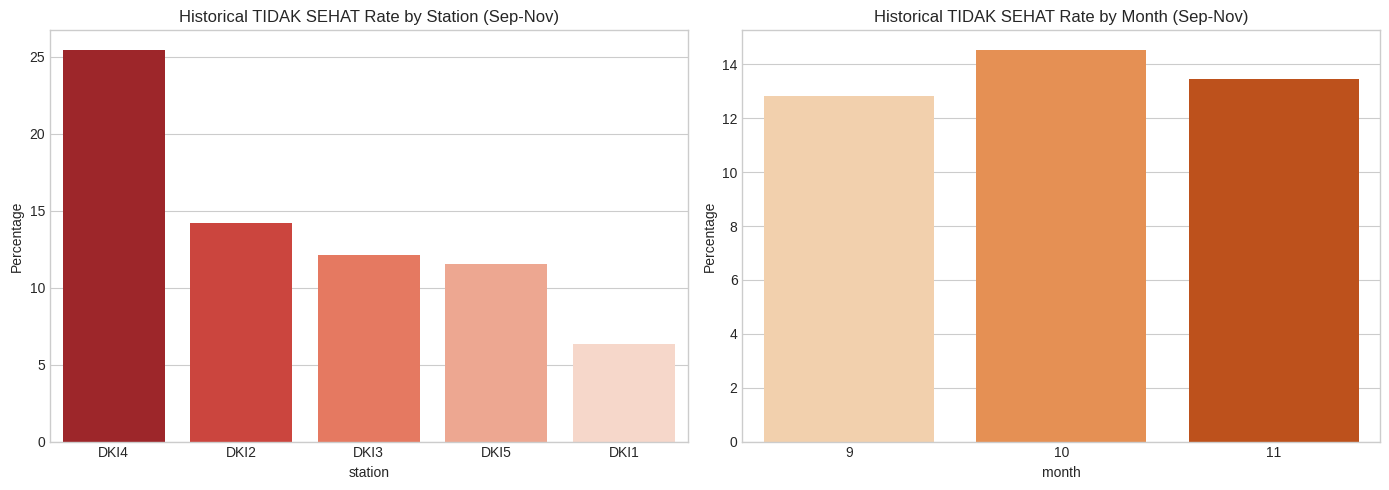

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=tidak_sehat_station,
    x="station",
    y="percentage",
    palette="Reds_r",
    ax=axes[0],
)
axes[0].set_title("Historical TIDAK SEHAT Rate by Station (Sep-Nov)")
axes[0].set_ylabel("Percentage")

sns.barplot(
    data=tidak_sehat_month,
    x="month",
    y="percentage",
    palette="Oranges",
    ax=axes[1],
)
axes[1].set_title("Historical TIDAK SEHAT Rate by Month (Sep-Nov)")
axes[1].set_ylabel("Percentage")

plt.tight_layout()
plt.show()


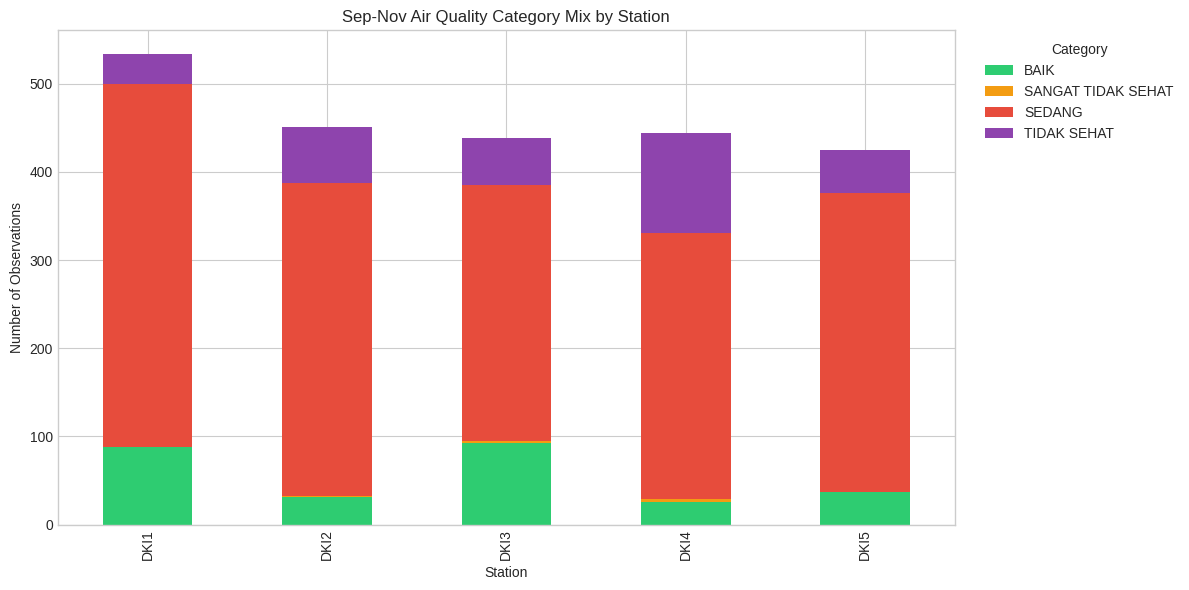

In [7]:
station_category_mix = (
    ispu_sep_nov.groupby(["station", "category"])
    .size()
    .unstack(fill_value=0)
)
station_category_mix = station_category_mix.reindex(target_stations)

ax = station_category_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"][: len(station_category_mix.columns)],
)
ax.set_title("Sep-Nov Air Quality Category Mix by Station")
ax.set_xlabel("Station")
ax.set_ylabel("Number of Observations")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [8]:
def get_season(month: int) -> str:
    return "Dry Season" if month in [6, 7, 8, 9] else "Wet Season"


ispu_data["season"] = ispu_data["month"].apply(get_season)

season_distribution = (
    ispu_data.groupby("season")["category"]
    .value_counts(normalize=True)
    .rename("ratio")
    .reset_index()
)

tidak_sehat_season = season_distribution[season_distribution["category"] == "TIDAK SEHAT"].copy()
tidak_sehat_season["percentage"] = tidak_sehat_season["ratio"] * 100
display(tidak_sehat_season[["season", "percentage"]])


,season,percentage
1,Dry Season,18.242492
7,Wet Season,12.159730


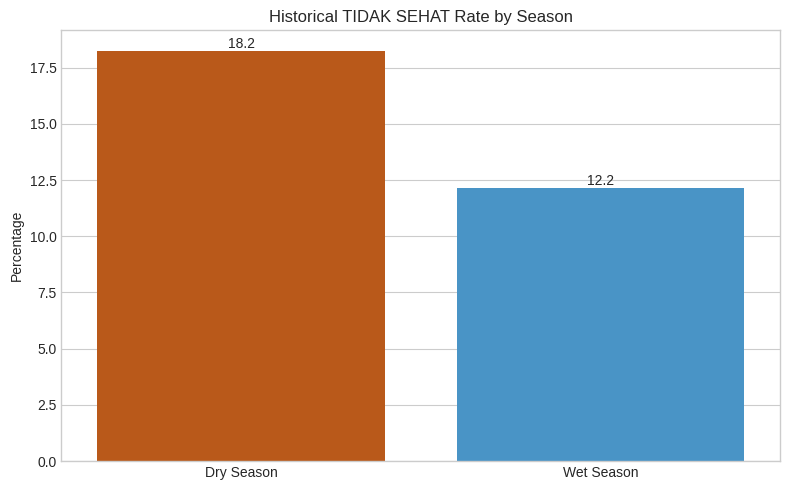

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=tidak_sehat_season,
    x="season",
    y="percentage",
    palette=["#d35400", "#3498db"],
    ax=ax,
)
ax.set_title("Historical TIDAK SEHAT Rate by Season")
ax.set_xlabel("")
ax.set_ylabel("Percentage")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.tight_layout()
plt.show()


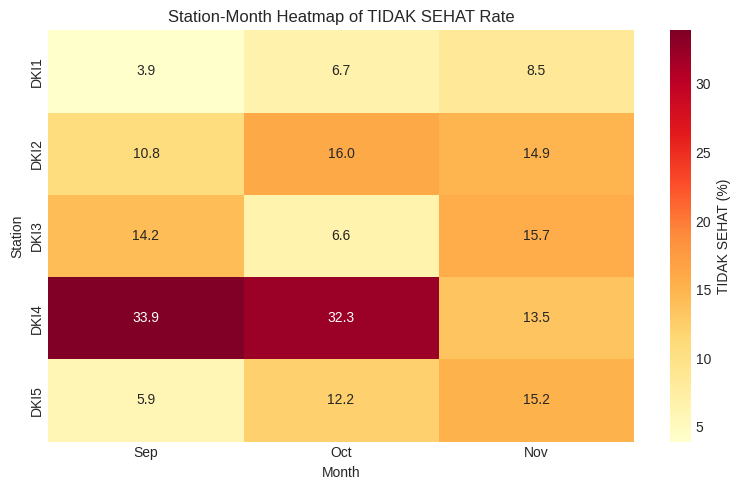

In [10]:
heatmap_data = (
    ispu_sep_nov.assign(is_unhealthy=lambda df: (df["category"] == "TIDAK SEHAT").astype(int))
    .groupby(["station", "month"])["is_unhealthy"]
    .mean()
    .unstack(fill_value=0)
    .reindex(target_stations)
)
heatmap_data = heatmap_data.rename(columns={9: "Sep", 10: "Oct", 11: "Nov"})

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data * 100, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "TIDAK SEHAT (%)"})
plt.title("Station-Month Heatmap of TIDAK SEHAT Rate")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


## 6. Weather interpretation

Beyond time and location patterns, weather conditions may also help explain elevated pollution risk. A compact comparison between `TIDAK SEHAT` days and other days provides useful environmental context for the forecasting strategy.


In [11]:
weather_merge = weather_data.copy()
merged = pd.merge(
    ispu_data[["date", "station", "category"]],
    weather_merge,
    on=["date", "station"],
    how="inner",
)

candidate_weather_cols = [
    "temperature_2m_mean (°C)",
    "precipitation_sum (mm)",
    "relative_humidity_2m_mean (%)",
    "wind_speed_10m_mean (km/h)",
    "surface_pressure_mean (hPa)",
]
available_weather_cols = [col for col in candidate_weather_cols if col in merged.columns]

summary_rows = []
for col in available_weather_cols:
    ts_mean = merged.loc[merged["category"] == "TIDAK SEHAT", col].mean()
    other_mean = merged.loc[merged["category"] != "TIDAK SEHAT", col].mean()
    summary_rows.append(
        {
            "feature": col,
            "tidak_sehat_mean": ts_mean,
            "other_mean": other_mean,
            "difference": ts_mean - other_mean,
        }
    )

weather_summary = pd.DataFrame(summary_rows).sort_values("difference", key=np.abs, ascending=False)
display(weather_summary)


,feature,tidak_sehat_mean,other_mean,difference
2,relative_humidity_2m_mean (%),79.923077,83.228996,-3.305919
1,precipitation_sum (mm),5.009413,7.125559,-2.116146
3,wind_speed_10m_mean (km/h),5.642510,6.482540,-0.840030
0,temperature_2m_mean (°C),26.890486,26.442149,0.448336
4,surface_pressure_mean (hPa),1006.575607,1006.963674,-0.388067


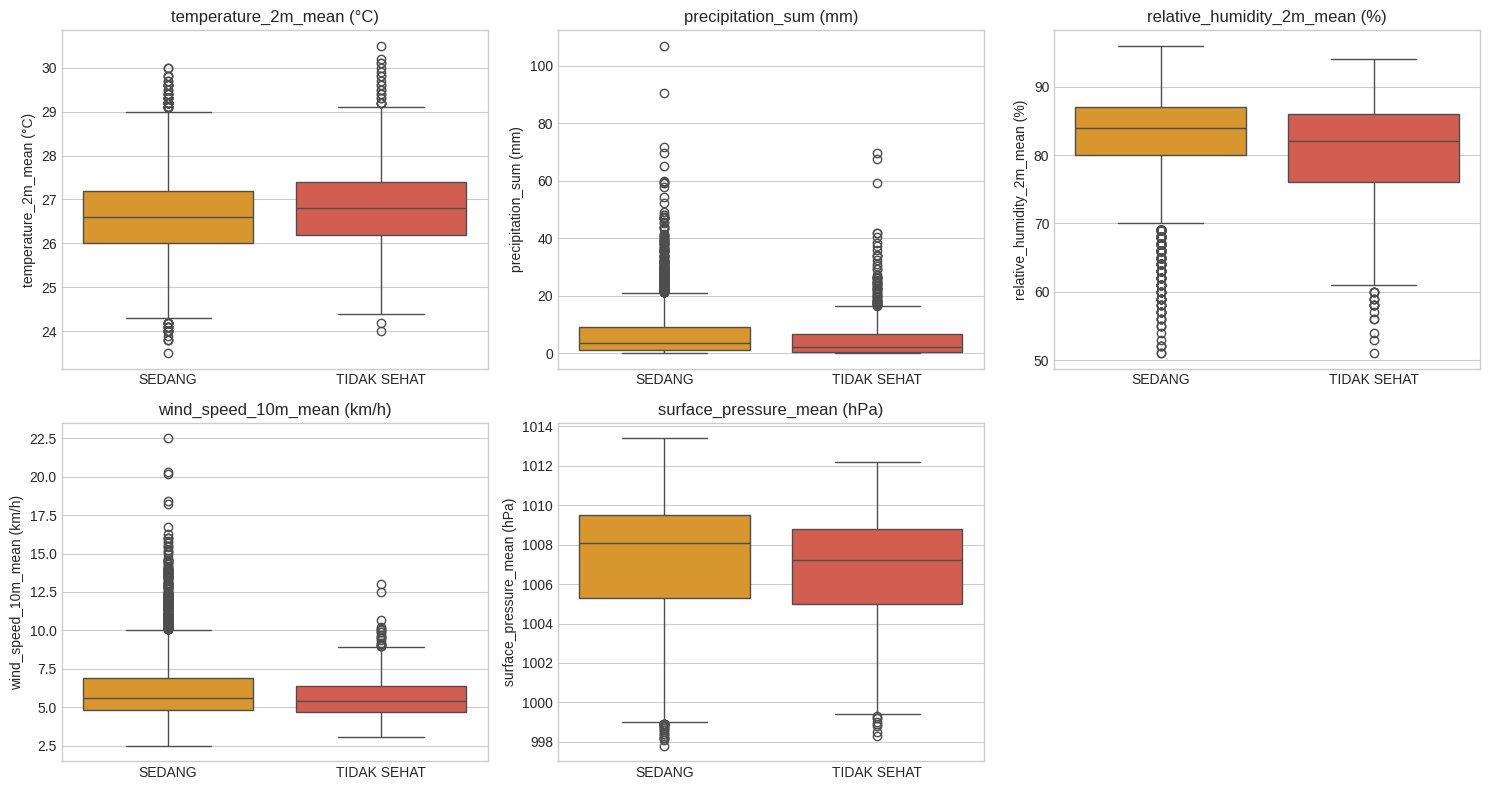

In [12]:
if available_weather_cols:
    n_cols = min(3, len(available_weather_cols))
    n_rows = (len(available_weather_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, available_weather_cols):
        sns.boxplot(
            data=merged[merged["category"].isin(["SEDANG", "TIDAK SEHAT"])],
            x="category",
            y=col,
            palette={"SEDANG": "#f39c12", "TIDAK SEHAT": "#e74c3c"},
            ax=ax,
        )
        ax.set_title(col)
        ax.set_xlabel("")

    for ax in axes[len(available_weather_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


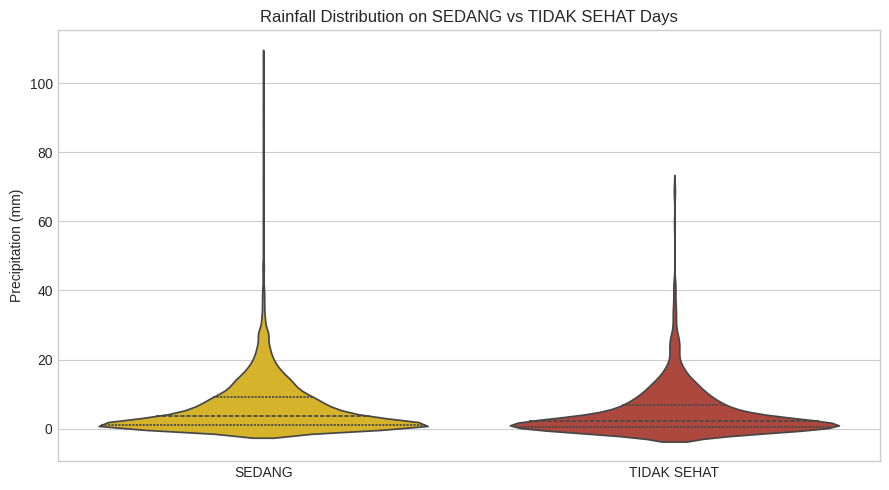

In [13]:
if "precipitation_sum (mm)" in merged.columns:
    chart_data = merged[merged["category"].isin(["SEDANG", "TIDAK SEHAT"])].copy()
    chart_data["category"] = pd.Categorical(chart_data["category"], categories=["SEDANG", "TIDAK SEHAT"], ordered=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.violinplot(
        data=chart_data,
        x="category",
        y="precipitation_sum (mm)",
        palette={"SEDANG": "#f1c40f", "TIDAK SEHAT": "#c0392b"},
        inner="quartile",
        ax=ax,
    )
    ax.set_title("Rainfall Distribution on SEDANG vs TIDAK SEHAT Days")
    ax.set_xlabel("")
    ax.set_ylabel("Precipitation (mm)")
    plt.tight_layout()
    plt.show()


## 7. Forecasting strategy

This notebook presents an interpretable forecasting strategy built from historical ISPU patterns and supporting weather context. The approach is designed to prioritize transparency, station-level insight, and seasonal pattern awareness:

- `DKI4` receives higher attention because of its stronger historical `TIDAK SEHAT` rate
- September is treated as the highest-risk month
- early October still carries residual dry-season risk
- November shifts more strongly toward `BAIK` and `SEDANG`

This forecasting design provides a strong analytical baseline and a clear foundation for future model development.


In [14]:
def generate_rule_based_forecast() -> pd.DataFrame:
    start = datetime(2025, 9, 1)
    end = datetime(2025, 11, 30)
    stations = ["DKI1", "DKI2", "DKI3", "DKI4", "DKI5"]

    rows = []
    current = start
    while current <= end:
        for station in stations:
            category = "SEDANG"
            month = current.month
            day = current.day

            if month == 11:
                if day == 6:
                    category = "BAIK"
                elif day == 7 and station in ["DKI1", "DKI2", "DKI4"]:
                    category = "BAIK"
                elif day in [8, 9] and station in ["DKI2", "DKI3", "DKI4", "DKI5"]:
                    category = "BAIK"
                elif day == 10 and station in ["DKI1", "DKI2", "DKI4", "DKI5"]:
                    category = "BAIK"
                elif day in [11, 12]:
                    category = "BAIK"
                elif day == 13 and station in ["DKI1", "DKI2", "DKI4", "DKI5"]:
                    category = "BAIK"
                elif day == 14:
                    category = "BAIK"
                elif day in [15, 16, 17] and station in ["DKI2", "DKI4"]:
                    category = "BAIK"
                elif day == 18 and station == "DKI2":
                    category = "BAIK"
                elif day == 20 and station in ["DKI2", "DKI4"]:
                    category = "BAIK"
                elif day == 21 and station in ["DKI1", "DKI2", "DKI4", "DKI5"]:
                    category = "BAIK"
                elif day == 24 and station in ["DKI2", "DKI3", "DKI4"]:
                    category = "BAIK"
                elif day in [25, 26] and station in ["DKI2", "DKI4"]:
                    category = "BAIK"

            elif month == 10:
                if day == 25 and station in ["DKI2", "DKI4", "DKI5"]:
                    category = "BAIK"
                elif day in [5, 6] and station in ["DKI4", "DKI2", "DKI5"]:
                    category = "TIDAK SEHAT"
                elif day in [17, 20, 21] and station == "DKI4":
                    category = "TIDAK SEHAT"

            elif month == 9:
                if day == 22 and station == "DKI2":
                    category = "BAIK"
                elif day == 23 and station == "DKI5":
                    category = "BAIK"
                elif 15 <= day <= 25:
                    if station == "DKI4" and day in [17, 19, 20, 24, 25]:
                        category = "TIDAK SEHAT"
                    elif station == "DKI2" and day in [17, 19, 25]:
                        category = "TIDAK SEHAT"
                    elif station == "DKI5" and day in [16, 17, 19, 24, 25]:
                        category = "TIDAK SEHAT"
                elif day <= 10 and station == "DKI4" and day == 8:
                    category = "TIDAK SEHAT"

            rows.append(
                {
                    "id": f"{current.strftime('%Y-%m-%d')}_{station}",
                    "category": category,
                }
            )
        current += timedelta(days=1)

    return pd.DataFrame(rows)


submission = generate_rule_based_forecast()
submission.head()


,id,category
0,2025-09-01_DKI1,SEDANG
1,2025-09-01_DKI2,SEDANG
2,2025-09-01_DKI3,SEDANG
3,2025-09-01_DKI4,SEDANG
4,2025-09-01_DKI5,SEDANG


In [15]:
print("Submission size:", len(submission))
display(submission["category"].value_counts())
display(submission.head(15))


Submission size: 455


category
SEDANG         368
BAIK            64
TIDAK SEHAT     23
Name: count, dtype: int64

,id,category
0,2025-09-01_DKI1,SEDANG
1,2025-09-01_DKI2,SEDANG
2,2025-09-01_DKI3,SEDANG
3,2025-09-01_DKI4,SEDANG
4,2025-09-01_DKI5,SEDANG
5,2025-09-02_DKI1,SEDANG
6,2025-09-02_DKI2,SEDANG
7,2025-09-02_DKI3,SEDANG
8,2025-09-02_DKI4,SEDANG
9,2025-09-02_DKI5,SEDANG


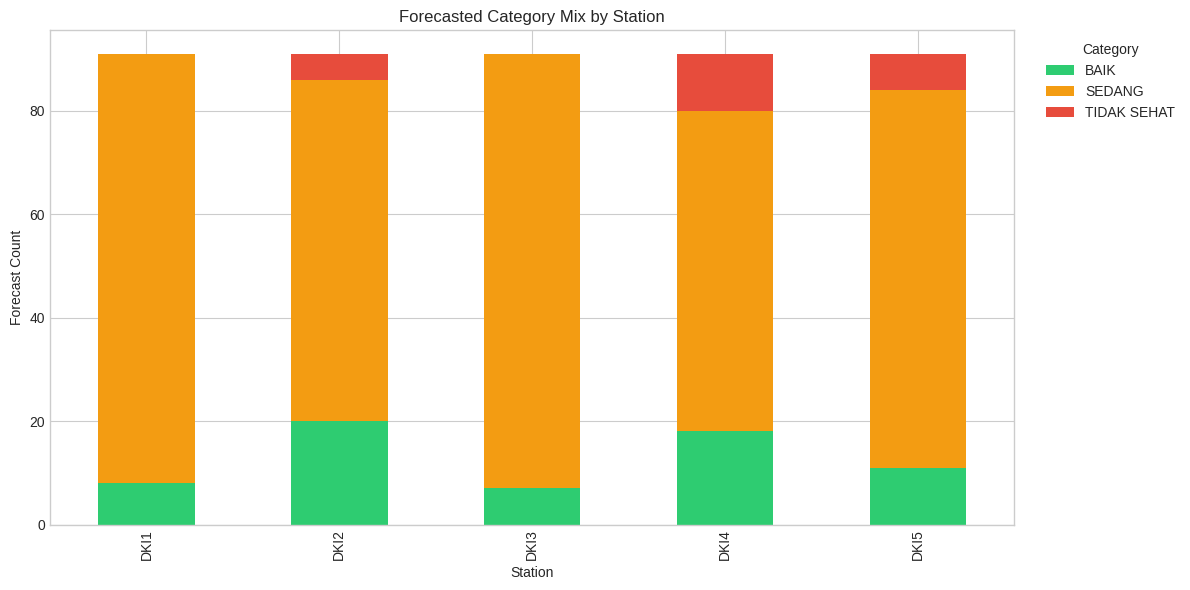

In [16]:
submission["station"] = submission["id"].str.split("_").str[-1]
submission["date"] = pd.to_datetime(submission["id"].str.split("_").str[0], errors="coerce")
submission["month"] = submission["date"].dt.month

forecast_mix = submission.groupby(["station", "category"]).size().unstack(fill_value=0).reindex(target_stations)
forecast_mix.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#2ecc71", "#f39c12", "#e74c3c"][: len(forecast_mix.columns)],
)
plt.title("Forecasted Category Mix by Station")
plt.xlabel("Station")
plt.ylabel("Forecast Count")
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


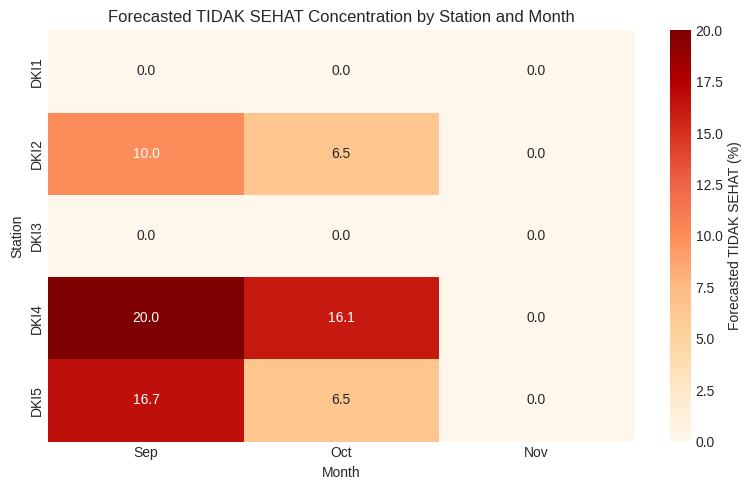

In [17]:
forecast_heatmap = (
    submission.dropna(subset=["month"])
    .assign(is_unhealthy=lambda df: (df["category"] == "TIDAK SEHAT").astype(int))
    .groupby(["station", "month"])["is_unhealthy"]
    .mean()
    .unstack(fill_value=0)
    .reindex(target_stations)
)

forecast_heatmap = forecast_heatmap.reindex(columns=[9, 10, 11], fill_value=0)
forecast_heatmap = forecast_heatmap.rename(columns={9: "Sep", 10: "Oct", 11: "Nov"})

plt.figure(figsize=(8, 5))
sns.heatmap(forecast_heatmap * 100, annot=True, fmt=".1f", cmap="OrRd", cbar_kws={"label": "Forecasted TIDAK SEHAT (%)"})
plt.title("Forecasted TIDAK SEHAT Concentration by Station and Month")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


In [18]:
output_path = '/kaggle/working/submission.csv'
submission.to_csv(output_path, index=False)

print("Saved submission to:", output_path)

Saved submission to: /kaggle/working/submission.csv


## 8. Conclusion

This project shows how historical environmental records can be converted into a clear forecasting workflow:

- raw multi-year data is consolidated and standardized
- meaningful temporal and geographic patterns are extracted
- supporting weather variables are used for interpretation
- insights are translated into an explainable forecasting baseline

## Key takeaways
- `DKI4` appears to be the most vulnerable station during the forecast period
- September is historically the riskiest month for `TIDAK SEHAT`
- dry-season conditions show a materially higher unhealthy-air proportion
- weather characteristics such as lower rainfall and weaker dispersion are plausible supporting factors

## Next improvements
Future iterations of this project can expand the forecasting pipeline with:

- time-aware machine learning validation
- gradient boosting models
- richer lag and rolling weather features
- class balancing strategies for rare unhealthy categories

Overall, this notebook highlights both technical execution and analytical reasoning in a concise, professional format.
